In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def run_eda(df, name="Dataset"):
    print(f"\n📊 EDA Report for: {name}")
    print("-" * 50)

    # Basic info
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("\nData Types:\n", df.dtypes)
    display(df.head())

    # Missing values
    print("\nMissing Values:\n", df.isnull().sum())

    # Duplicates
    print("\nDuplicate Rows:", df.duplicated().sum())

    # Summary stats
    print("\nSummary Statistics:")
    display(df.describe(include="all"))

    # Unique values in key columns
    key_cols = [col for col in df.columns if df[col].nunique() < 20 and df[col].dtype == "object"]
    for col in key_cols:
        print(f"\nUnique values in '{col}':", df[col].unique())

    # Date range check
    date_cols = [col for col in df.columns if "date" in col or "at" in col or "timestamp" in col]
    for col in date_cols:
        try:
            df[col] = pd.to_datetime(df[col], errors="coerce")
            print(f"{col} range:", df[col].min(), "→", df[col].max())
        except:
            print(f"{col} could not be parsed as datetime.")

    # Quick plot for categorical columns
    for col in key_cols[:3]:  # limit to 3 plots
        plt.figure(figsize=(6, 3))
        sns.countplot(data=df, x=col)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


📊 EDA Report for: Customer Tickets
--------------------------------------------------
Shape: (28587, 16)
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

Data Types:
 subject     object
body        object
answer      object
type        object
queue       object
priority    object
language    object
version      int64
tag_1       object
tag_2       object
tag_3       object
tag_4       object
tag_5       object
tag_6       object
tag_7       object
tag_8       object
dtype: object


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN



Missing Values:
 subject      3838
body            0
answer          7
type            0
queue           0
priority        0
language        0
version         0
tag_1           0
tag_2          13
tag_3         136
tag_4        3058
tag_5       14042
tag_6       22713
tag_7       26547
tag_8       28022
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,24749,28587,28580,28587,28587,28587,28587,28587.000000,28587,28574,28451,25529,14545,5874,2040,565
unique,24749,28587,28580,4,10,3,2,NaN,116,256,392,554,602,575,427,224
top,Inquiry About Project Management Features,Looking for detailed information on the projec...,"Dear [Name], thank you for your email regardin...",Incident,Technical Support,medium,en,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Tech Support
freq,1,1,1,11466,8362,11515,16338,NaN,5880,5903,6121,6568,4617,1847,391,77
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Unique values in 'type': ['Incident' 'Request' 'Problem' 'Change']

Unique values in 'queue': ['Technical Support' 'Returns and Exchanges' 'Billing and Payments'
 'Sales and Pre-Sales' 'Service Outages and Maintenance' 'Product Support'
 'IT Support' 'Customer Service' 'Human Resources' 'General Inquiry']

Unique values in 'priority': ['high' 'medium' 'low']

Unique values in 'language': ['de' 'en']


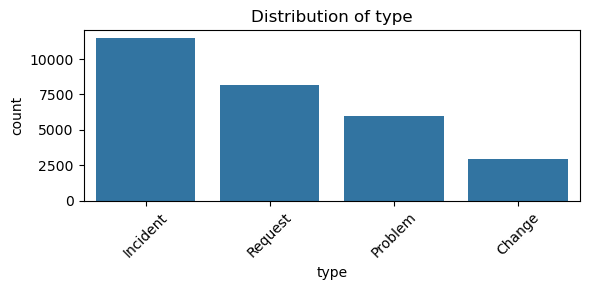

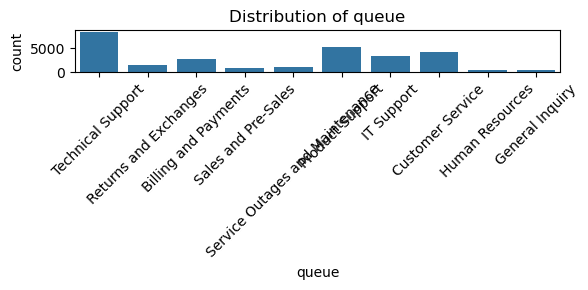

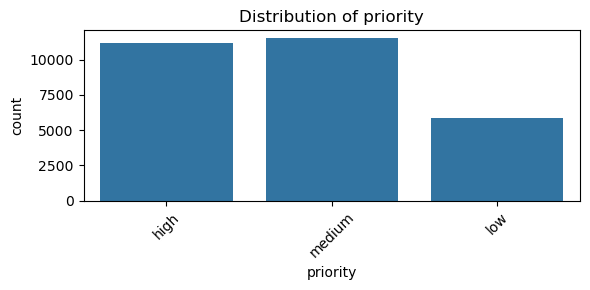

In [4]:
df_tickets = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics\data\customer_tickets.csv")
df_incidents = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics\data\incident_event_log.csv")
df_support = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics\data\it_support_data.csv")
df_metrics = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics\data\metrics.csv")
df_tech = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics\data\technical_support.csv")

run_eda(df_tickets, "Customer Tickets")

In [5]:

ticket_mapping = {
    "subject": "subject",
    "body": "body",
    "answer": "survey_results",        # maps to survey_results in schema
    "ticket_type": "topic",            # schema expects 'topic'
    "assignment_group": "assignment_group",  # will join to dim_agent
    "priority_level": "priority_name",       # will join to dim_priority
    "language": "source",              # schema has 'source'
    "product_version": "product_group",# schema has 'product_group'
    "tags": "support_level"            # schema has 'support_level'
}

df_tickets = df_tickets.rename(columns=ticket_mapping)

save_path = r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics"
df_tickets.to_csv(save_path + r"\cleaned_customer_tickets.csv", index=False)


📊 EDA Report for: Incident Event Log
--------------------------------------------------
Shape: (119998, 36)
Columns: ['number', 'incident_state', 'active', 'reassignment_count', 'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at']

Data Types:
 number                     object
incident_state             object
active                       bool
reassignment_count          int64
reopen_count                int64
sys_mod_count               int64
made_sla                     bool
caller_id                  object
opened_by                  object
opened_at                  object
sys_created_

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00



Missing Values:
 number                     0
incident_state             0
active                     0
reassignment_count         0
reopen_count               0
sys_mod_count              0
made_sla                   0
caller_id                  0
opened_by                  0
opened_at                  0
sys_created_by             0
sys_created_at             0
sys_updated_by             0
sys_updated_at             0
contact_type               0
location                   0
category                   0
subcategory                0
u_symptom                  0
cmdb_ci                    0
impact                     0
urgency                    0
priority                   0
assignment_group           0
assigned_to                0
knowledge                  0
u_priority_confirmation    0
notify                     0
problem_id                 0
rfc                        0
vendor                     0
caused_by                  0
closed_code                0
resolved_by              

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
count,119998,119998,119998,119998.000000,119998.000000,119998.000000,119998,119998,119998,119998,...,119998,119998,119998,119998,119998,119998,119998,119998,119998,119998
unique,20769,9,2,NaN,NaN,NaN,2,4829,157,16349,...,2,2,216,163,5,3,17,191,15333,2013
top,INC0019396,Active,True,NaN,NaN,NaN,True,Caller 1904,Opened by 17,14/4/2016 20:42,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,?,24/3/2016 18:59
freq,58,33582,99172,NaN,NaN,NaN,111738,1421,33079,58,...,87564,119879,118061,119116,119816,119980,74039,14398,2861,3324
mean,NaN,NaN,NaN,1.151236,0.021025,5.199312,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.782823,0.196173,7.804628,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,0.000000,3.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,0.000000,7.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Unique values in 'incident_state': ['New' 'Resolved' 'Closed' 'Active' 'Awaiting User Info'
 'Awaiting Problem' 'Awaiting Vendor' 'Awaiting Evidence' '-100']

Unique values in 'contact_type': ['Phone' 'Email']

Unique values in 'impact': ['2 - Medium' '1 - High' '3 - Low']

Unique values in 'urgency': ['2 - Medium' '3 - Low' '1 - High']

Unique values in 'priority': ['3 - Moderate' '2 - High' '4 - Low' '1 - Critical']

Unique values in 'notify': ['Do Not Notify' 'Send Email']

Unique values in 'vendor': ['?' 'code 8s' 'Vendor 3' 'Vendor 2' 'Vendor 1']

Unique values in 'caused_by': ['?' 'CHG0000132' 'CHG0000097']

Unique values in 'closed_code': ['code 5' 'code 10' 'code 3' 'code 7' 'code 6' 'code 1' 'code 11' 'code 8'
 'code 4' 'code 9' 'code 2' 'code 17' 'code 16' '?' 'code 15' 'code 13'
 'code 14']
incident_state range: NaT → NaT


...

sys_updated_by range: NaT → NaT


C:\Users\HP\AppData\Local\Temp\ipykernel_19040\1043742484.py:34: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


sys_updated_at range: 2016-02-29 01:23:00 → 2017-02-15 15:00:00
location range: NaT → NaT
category range: NaT → NaT
subcategory range: NaT → NaT
u_priority_confirmation range: NaT → NaT


C:\Users\HP\AppData\Local\Temp\ipykernel_19040\1043742484.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\HP\AppData\Local\Temp\ipykernel_19040\1043742484.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\HP\AppData\Local\Temp\ipykernel_19040\1043742484.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\HP\AppData\Local\Temp\ipykernel_19040\1043742484.py:34: UserWarning: Parsing dates in

resolved_at range: 2016-02-29 09:04:00 → 2017-02-10 14:18:00
closed_at range: 2016-01-04 00:59:00 → 2017-10-01 01:00:00


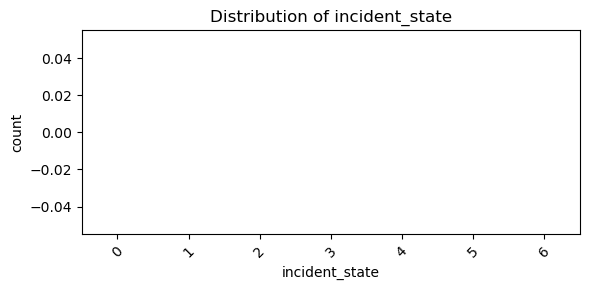

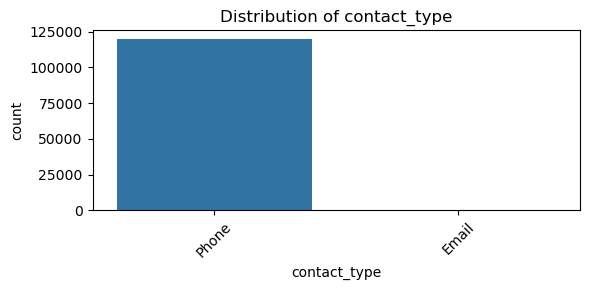

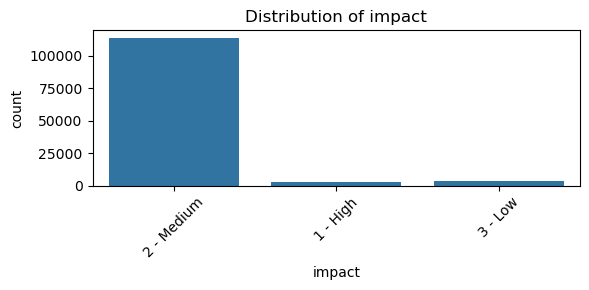

In [6]:
run_eda(df_incidents, "Incident Event Log")

In [7]:
import numpy as np

# Step 1: Parse datetime columns
date_cols = ["opened_at", "sys_created_at", "sys_updated_at", "resolved_at", "closed_at"]
for col in date_cols:
    df_incidents[col] = pd.to_datetime(df_incidents[col], errors="coerce", dayfirst=True)

# Step 2: Clean categorical placeholders
placeholder_cols = ["vendor", "caused_by", "problem_id", "rfc"]
for col in placeholder_cols:
    df_incidents[col] = df_incidents[col].replace("?", np.nan)

# Step 3: Normalize incident_state
df_incidents["incident_state"] = df_incidents["incident_state"].replace("-100", np.nan)

# Convert everything to string first, then clean
df_incidents["incident_state"] = (
    df_incidents["incident_state"]
    .astype(str)                # ensures all values are strings
    .str.strip()
    .str.lower()
    .replace("nan", np.nan)     # convert back NaN strings to real NaN
)
# Step 4: Standardize priority/impact/urgency
def extract_numeric(val):
    try:
        return int(val.split("-")[0].strip())
    except:
        return np.nan

df_incidents["impact"] = df_incidents["impact"].apply(extract_numeric)
df_incidents["urgency"] = df_incidents["urgency"].apply(extract_numeric)

# Priority mapping → dim_priority
priority_map = {
    "1 - Critical": "critical",
    "2 - High": "high",
    "3 - Moderate": "moderate",
    "4 - Low": "low"
}
df_incidents["priority_level"] = df_incidents["priority"].map(priority_map)

# Step 5: Convert booleans to integers
bool_cols = ["active", "made_sla", "knowledge", "u_priority_confirmation"]
for col in bool_cols:
    df_incidents[col] = df_incidents[col].astype(int)

# Step 6: Standardize text fields
df_incidents["assignment_group"] = df_incidents["assignment_group"].str.strip()
df_incidents["assigned_to"] = df_incidents["assigned_to"].str.strip()
df_incidents["contact_type"] = df_incidents["contact_type"].str.strip().str.lower()

# Step 7: Reset index
df_incidents = df_incidents.reset_index(drop=True)

# Step 8: Save cleaned dataset
save_path = r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics\data"
df_incidents.to_csv(save_path + r"\cleaned_incident_event_log.csv", index=False)

In [8]:
incident_mapping = {
    "number": "incident_id",           # schema requires incident_id
    "incident_state": "incident_state",
    "active": "active",
    "reassignment_count": "reassignment_count",
    "reopen_count": "reopen_count",
    "sys_mod_count": "modification_count",   # not in schema, drop later if unused
    "made_sla": "made_sla",
    "caller_id": "caller_id",
    "opened_at": "opened_at",
    "sys_created_at": "acknowledged_at",     # schema has acknowledged_at
    "sys_updated_at": "updated_at",          # not in schema, drop later if unused
    "contact_type": "contact_type",
    "u_symptom": "u_symptom",
    "cmdb_ci": "configuration_item",         # not in schema, drop later if unused
    "impact": "impact",
    "urgency": "urgency",
    "priority": "priority_id",               # FK to dim_priority
    "assignment_group": "assignment_group",
    "assigned_to": "assigned_to",
    "knowledge": "knowledge_flag",           # not in schema, drop later if unused
    "u_priority_confirmation": "priority_confirmed_flag", # not in schema, drop later if unused
    "notify": "notification_type",           # not in schema, drop later if unused
    "closed_code": "closed_code",
    "resolved_by": "resolved_by",
    "resolved_at": "resolved_at",
    "closed_at": "closed_at",
    "priority_level": "priority_name"        # FK to dim_priority
}

df_incidents = df_incidents.rename(columns=incident_mapping)

# Step 6: Save cleaned dataset
save_path = r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics"
df_incidents.to_csv(save_path + r"\cleaned_incident_event_log.csv", index=False)

In [9]:
print(df_incidents.columns)

Index(['incident_id', 'incident_state', 'active', 'reassignment_count',
       'reopen_count', 'modification_count', 'made_sla', 'caller_id',
       'opened_by', 'opened_at', 'sys_created_by', 'acknowledged_at',
       'sys_updated_by', 'updated_at', 'contact_type', 'location', 'category',
       'subcategory', 'u_symptom', 'configuration_item', 'impact', 'urgency',
       'priority_id', 'assignment_group', 'assigned_to', 'knowledge_flag',
       'priority_confirmed_flag', 'notification_type', 'problem_id', 'rfc',
       'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at',
       'closed_at', 'priority_name'],
      dtype='object')



📊 EDA Report for: IT Support Data
--------------------------------------------------
Shape: (29651, 5)
Columns: ['Unnamed: 0', 'Body', 'Department', 'Priority', 'Tags']

Data Types:
 Unnamed: 0     int64
Body          object
Department    object
Priority      object
Tags          object
dtype: object


,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."



Missing Values:
 Unnamed: 0    0
Body          1
Department    0
Priority      0
Tags          0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,Unnamed: 0,Body,Department,Priority,Tags
count,29651.000000,29650,29651,29651,29651
unique,NaN,25055,10,3,12946
top,NaN,The data analytics tool experiences sluggish p...,Technical Support,medium,"['Bug', 'Performance', 'IT', 'Tech Support']"
freq,NaN,2,8617,12126,878
mean,14825.000000,NaN,NaN,NaN,NaN
std,8559.650752,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,7412.500000,NaN,NaN,NaN,NaN
50%,14825.000000,NaN,NaN,NaN,NaN
75%,22237.500000,NaN,NaN,NaN,NaN



Unique values in 'Department': ['Technical Support' 'Returns and Exchanges' 'Billing and Payments'
 'Sales and Pre-Sales' 'Service Outages and Maintenance' 'Product Support'
 'IT Support' 'Customer Service' 'Human Resources' 'General Inquiry']

Unique values in 'Priority': ['high' 'medium' 'low']


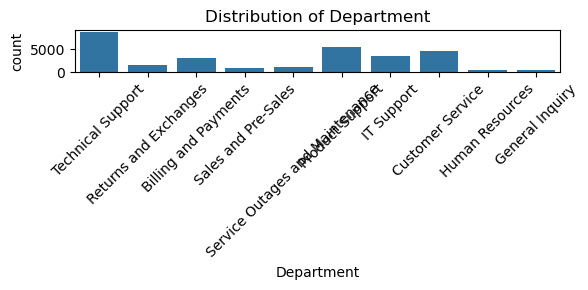

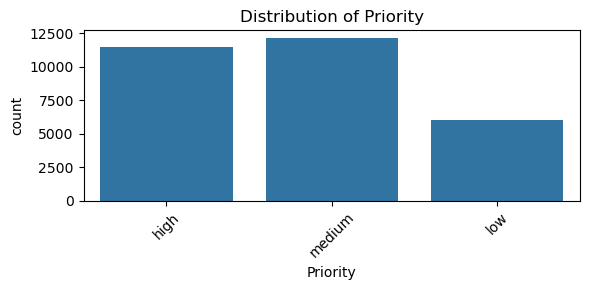

In [10]:
run_eda(df_support, "IT Support Data")

In [22]:
import pandas as pd
import numpy as np

# Assume df_support is already loaded



# Step 4: Map to schema fields (fact_ticket)
support_mapping = {
    "Body": "body",
    "Department": "assignment_group",   # will join to dim_agent
    "Priority": "priority_name",        # will join to dim_priority
    "Tags": "support_level"             # schema field
}

df_support = df_support.rename(columns=support_mapping)

# Step 5: Reset index
df_support = df_support.reset_index(drop=True)

# Step 6: Save cleaned dataset
save_path = r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics"
df_support.to_csv(save_path + r"\cleaned_it_support_data.csv", index=False)

In [11]:
run_eda(df_metrics, "Metrics")


📊 EDA Report for: Metrics
--------------------------------------------------
Shape: (84000, 9)
Columns: ['metric_id', 'site_id', 'asset_id', 'timestamp_utc', 'cpu_util_pct', 'mem_util_pct', 'link_util_pct', 'latency_ms', 'packet_loss_pct']

Data Types:
 metric_id            int64
site_id              int64
asset_id             int64
timestamp_utc       object
cpu_util_pct         int64
mem_util_pct         int64
link_util_pct        int64
latency_ms           int64
packet_loss_pct    float64
dtype: object


,metric_id,site_id,asset_id,timestamp_utc,cpu_util_pct,mem_util_pct,link_util_pct,latency_ms,packet_loss_pct
0,1,1,1,2026-01-01 00:00:00,38,53,80,27,1.0
1,2,1,1,2026-01-01 01:00:00,39,81,59,62,0.5
2,3,1,1,2026-01-01 02:00:00,65,40,94,186,2.0
3,4,1,1,2026-01-01 03:00:00,91,56,34,126,0.1
4,5,1,1,2026-01-01 04:00:00,66,80,29,146,2.0



Missing Values:
 metric_id          0
site_id            0
asset_id           0
timestamp_utc      0
cpu_util_pct       0
mem_util_pct       0
link_util_pct      0
latency_ms         0
packet_loss_pct    0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,metric_id,site_id,asset_id,timestamp_utc,cpu_util_pct,mem_util_pct,link_util_pct,latency_ms,packet_loss_pct
count,84000.000000,84000.000000,84000.000000,84000,84000.000000,84000.000000,84000.000000,84000.000000,84000.000000
unique,NaN,NaN,NaN,168,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,500,NaN,NaN,NaN,NaN,NaN
mean,42000.500000,5.500000,25.500000,NaN,56.963488,59.580440,54.594881,104.447607,0.720101
std,24248.855643,2.872298,14.430956,NaN,21.639550,17.300757,26.032551,54.805540,0.730081
min,1.000000,1.000000,1.000000,NaN,20.000000,30.000000,10.000000,10.000000,0.000000
25%,21000.750000,3.000000,13.000000,NaN,38.000000,45.000000,32.000000,57.000000,0.100000
50%,42000.500000,5.500000,25.500000,NaN,57.000000,60.000000,55.000000,105.000000,0.500000
75%,63000.250000,8.000000,38.000000,NaN,76.000000,75.000000,77.000000,152.000000,1.000000


timestamp_utc range: 2026-01-01 00:00:00 → 2026-01-07 23:00:00
latency_ms range: 1970-01-01 00:00:00.000000010 → 1970-01-01 00:00:00.000000199


In [23]:
import pandas as pd

# Drop asset_id safely (only if present)
df_metrics = df_metrics.drop(columns=["asset_id"], errors="ignore")

# Parse timestamp
df_metrics["timestamp_utc"] = pd.to_datetime(df_metrics["timestamp_utc"], errors="coerce")

# Ensure numeric types
df_metrics["cpu_util_pct"] = df_metrics["cpu_util_pct"].astype(float)
df_metrics["mem_util_pct"] = df_metrics["mem_util_pct"].astype(float)
df_metrics["link_util_pct"] = df_metrics["link_util_pct"].astype(float)
df_metrics["latency_ms"] = pd.to_numeric(df_metrics["latency_ms"], errors="coerce").astype(float)
df_metrics["packet_loss_pct"] = df_metrics["packet_loss_pct"].astype(float)

# Reset index
df_metrics = df_metrics.reset_index(drop=True)
# Step 6: Save cleaned dataset
save_path = r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics"
df_metrics.to_csv(save_path + r"\cleaned_metrics_data.csv", index=False)


📊 EDA Report for: Technical Support
--------------------------------------------------
Shape: (2330, 22)
Columns: ['Status', 'Ticket ID', 'Priority', 'Source', 'Topic', 'Agent Group', 'Agent Name', 'Created time', 'Expected SLA to resolve', 'Expected SLA to first response', 'First response time', 'SLA For first response', 'Resolution time', 'SLA For Resolution', 'Close time', 'Agent interactions', 'Survey results', 'Product group', 'Support Level', 'Country', 'Latitude', 'Longitude']

Data Types:
 Status                             object
Ticket ID                           int64
Priority                           object
Source                             object
Topic                              object
Agent Group                        object
Agent Name                         object
Created time                       object
Expected SLA to resolve            object
Expected SLA to first response     object
First response time                object
SLA For first response            

,Status,Ticket ID,Priority,Source,Topic,Agent Group,Agent Name,Created time,Expected SLA to resolve,Expected SLA to first response,...,Resolution time,SLA For Resolution,Close time,Agent interactions,Survey results,Product group,Support Level,Country,Latitude,Longitude
0,Closed,1012,Low,Email,Feature request,1st line support,Kristos Westoll,2023-01-02 00:58:36,2023-01-04 00:58:36,2023-01-02 01:58:36,...,2023-01-04 00:31:51.694,Within SLA,2023-01-04 04:02:59.013,1.0,3.0,Custom software development,Tier 1,Republic of Ireland,53.094024,-8.019675
1,In progress,1013,High,Phone,Product setup,2nd line support,Adolpho Messingham,2023-01-02 07:27:25,2023-01-04 07:27:25,2023-01-02 07:29:25,...,NaN,SLA Violated,NaN,3.0,NaN,Other,Tier 2,Italy,43.036776,12.678565
2,Resolved,1014,Low,Chat,Purchasing and invoicing,1st line support,Bernard Beckley,2023-01-02 06:59:04,2023-01-03 06:59:04,2023-01-02 07:01:04,...,2023-01-02 22:45:32.974,Within SLA,NaN,2.0,NaN,Custom software development,Tier 1,Austria,47.696472,13.345735
3,Closed,1015,Medium,Email,Pricing and licensing,1st line support,Connor Danielovitch,2023-01-03 03:09:39,2023-01-05 03:09:39,2023-01-03 04:09:39,...,2023-01-04 14:32:34.979,Within SLA,2023-01-08 04:24:54.771,10.0,4.0,Ready to use Software,Tier 1,Spain,39.673370,-4.767726
4,Closed,1016,Low,Email,Product setup,1st line support,Kristos Westoll,2023-01-03 00:03:58,2023-01-05 00:03:58,2023-01-03 01:03:58,...,2023-01-04 12:03:05.986,Within SLA,2023-01-06 06:05:08.637,1.0,2.0,Other,Tier 1,Austria,47.696472,13.345735



Missing Values:
 Status                               0
Ticket ID                            0
Priority                             0
Source                               0
Topic                                0
Agent Group                          0
Agent Name                           0
Created time                         0
Expected SLA to resolve              0
Expected SLA to first response       0
First response time                 18
SLA For first response               0
Resolution time                    418
SLA For Resolution                   0
Close time                        1157
Agent interactions                  18
Survey results                    1157
Product group                        0
Support Level                        0
Country                              0
Latitude                             0
Longitude                            0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,Status,Ticket ID,Priority,Source,Topic,Agent Group,Agent Name,Created time,Expected SLA to resolve,Expected SLA to first response,...,Resolution time,SLA For Resolution,Close time,Agent interactions,Survey results,Product group,Support Level,Country,Latitude,Longitude
count,2330,2330.000000,2330,2330,2330,2330,2330,2330,2330,2330,...,1912,2330,1173,2312.000000,1173.000000,2330,2330,2330,2330.000000,2330.000000
unique,4,NaN,3,3,8,2,8,2330,2330,2330,...,1912,2,1173,NaN,NaN,4,2,12,NaN,NaN
top,Closed,NaN,Low,Email,Product setup,1st line support,Nicola Wane,2023-12-30 19:49:51,2024-01-01 19:49:51,2023-12-30 20:49:51,...,2024-01-01 10:17:15.196,Within SLA,2024-01-02 07:37:59.534,NaN,NaN,Ready to use Software,Tier 1,Germany,NaN,NaN
freq,1173,NaN,1192,1234,630,1770,367,1,1,1,...,1,1547,1,NaN,NaN,1010,1770,306,NaN,NaN
mean,NaN,2481.857082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.470156,3.510656,NaN,NaN,NaN,48.260756,9.849723
std,NaN,858.040637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,8.130958,1.240361,NaN,NaN,NaN,5.085409,9.814618
min,NaN,1012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,39.368279,-8.019675
25%,NaN,1726.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,NaN,43.036776,2.349014
50%,NaN,2480.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN,NaN,48.864716,12.678565
75%,NaN,3233.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.000000,4.000000,NaN,NaN,NaN,52.536273,15.474913



Unique values in 'Status': ['Closed' 'In progress' 'Resolved' 'Open']

Unique values in 'Priority': ['Low' 'High' 'Medium']

Unique values in 'Source': ['Email' 'Phone' 'Chat']

Unique values in 'Topic': ['Feature request' 'Product setup' 'Purchasing and invoicing'
 'Pricing and licensing' 'Other' 'Bug report' 'Training request'
 'Pricing and Licensing']

Unique values in 'Agent Group': ['1st line support' '2nd line support']

Unique values in 'Agent Name': ['Kristos Westoll' 'Adolpho Messingham' 'Bernard Beckley'
 'Connor Danielovitch' 'Sheela Cutten' 'Michele Whyatt' 'Nicola Wane'
 'Heather Urry']

Unique values in 'SLA For first response': ['Within SLA' 'SLA Violated']

Unique values in 'SLA For Resolution': ['Within SLA' 'SLA Violated']

Unique values in 'Product group': ['Custom software development' 'Other' 'Ready to use Software'
 'Training and Consulting Services']

Unique values in 'Support Level': ['Tier 1' 'Tier 2']

Unique values in 'Country': ['Republic of Ireland' 'Italy

C:\Users\HP\AppData\Local\Temp\ipykernel_19040\1043742484.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


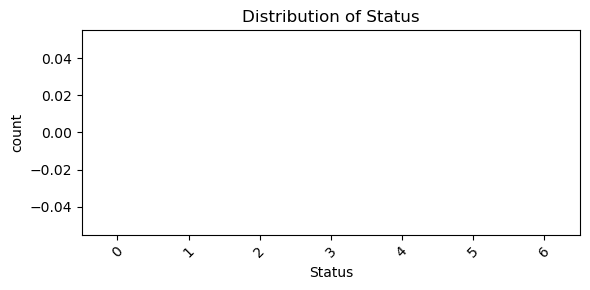

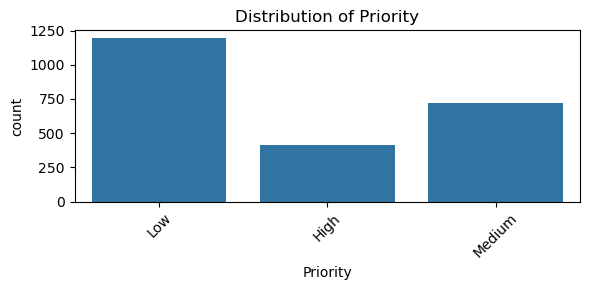

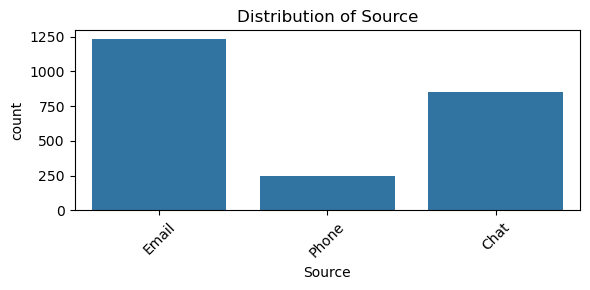

In [12]:
run_eda(df_tech, "Technical Support")

In [27]:
import pandas as pd
import numpy as np



ticket_mapping = {
    "body": "body",
    "assignment_group": "assignment_group",
    "priority_name": "priority_name",
    "support_level": "support_level"
}

df_support = df_support.rename(columns=ticket_mapping)

# Step 6: Save cleaned dataset
save_path = r"C:\Users\HP\OneDrive\Desktop\it-infra-sla-analytics"
df_support.to_csv(save_path + r"\cleaned_technical_support.csv", index=False)

In [25]:
print(df_support.columns.tolist())

['body', 'assignment_group', 'priority_name', 'support_level']
